<a href="https://colab.research.google.com/github/Zafar26335/supply-chain-analytics-portfolio-SZN/blob/main/00-%20Initial%20working/First%20Program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Chenab_Motors_Procurement_Practice_Dataset.xlsx",sheet_name="Procurement_Data")

In [4]:
print(df.shape)

(10050, 22)


In [5]:
print(df.head())

   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...  2024-07-23

## Top 10 Vendors by Volume

In [6]:
# Step 1: Data Cleaning - Check 'Quantity' column data type and missing values
# Print the information about 'Quantity' and 'Vendor' columns to understand their current state.
print("Data types of relevant columns:")
print(df[['Quantity', 'Vendor']].info())

# Convert 'Quantity' to a numeric type, coercing any non-numeric values to NaN (Not a Number).
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Fill any NaN values in the 'Quantity' column with 0, assuming that a missing quantity means zero items.
df['Quantity'] = df['Quantity'].fillna(0)

# Verify that there are no more missing values in the 'Quantity' column after cleaning.
print("\nMissing values after cleaning in 'Quantity' column:")
print(df['Quantity'].isnull().sum())

Data types of relevant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Quantity  10050 non-null  int64 
 1   Vendor    9930 non-null   object
dtypes: int64(1), object(1)
memory usage: 157.2+ KB
None

Missing values after cleaning in 'Quantity' column:
0


In [7]:
# Step 2: Calculations - Group by 'Vendor' and sum 'Quantity' to find total volume
# Aggregate the data by 'Vendor', summing the 'Quantity' for each vendor.
# Then, use .nlargest(10) to get the top 10 vendors with the highest total quantity.
# Reset the index to turn the 'Vendor' and summed 'Quantity' into a DataFrame.
top_10_vendors_by_volume = df.groupby('Vendor')['Quantity'].sum().nlargest(10).reset_index()

# Rename the 'Quantity' column to 'Total Procurement Volume' for clarity in the output.
top_10_vendors_by_volume.rename(columns={'Quantity': 'Total Procurement Volume'}, inplace=True)

# Display the resulting DataFrame showing the top 10 vendors and their total procurement volume.
print("Top 10 Vendors by Procurement Volume:")
display(top_10_vendors_by_volume)

Top 10 Vendors by Procurement Volume:


,Vendor,Total Procurement Volume
0,Al-Amin Auto Components,21760
1,Karachi Steel Traders,11462
2,Zaman Brothers Trading,8565
3,Anwar Electric Works,7888
4,TCS Cargo Services,4762
5,Gulistan Logistics,4420
6,United Rubber Industries,3965
7,Sindh Spinners Co.,3870
8,Speedline Logistics,3314
9,Reliance Packaging,3180


/tmp/ipykernel_2657/300407615.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Procurement Volume', y='Vendor', data=top_10_vendors_by_volume, palette='viridis')


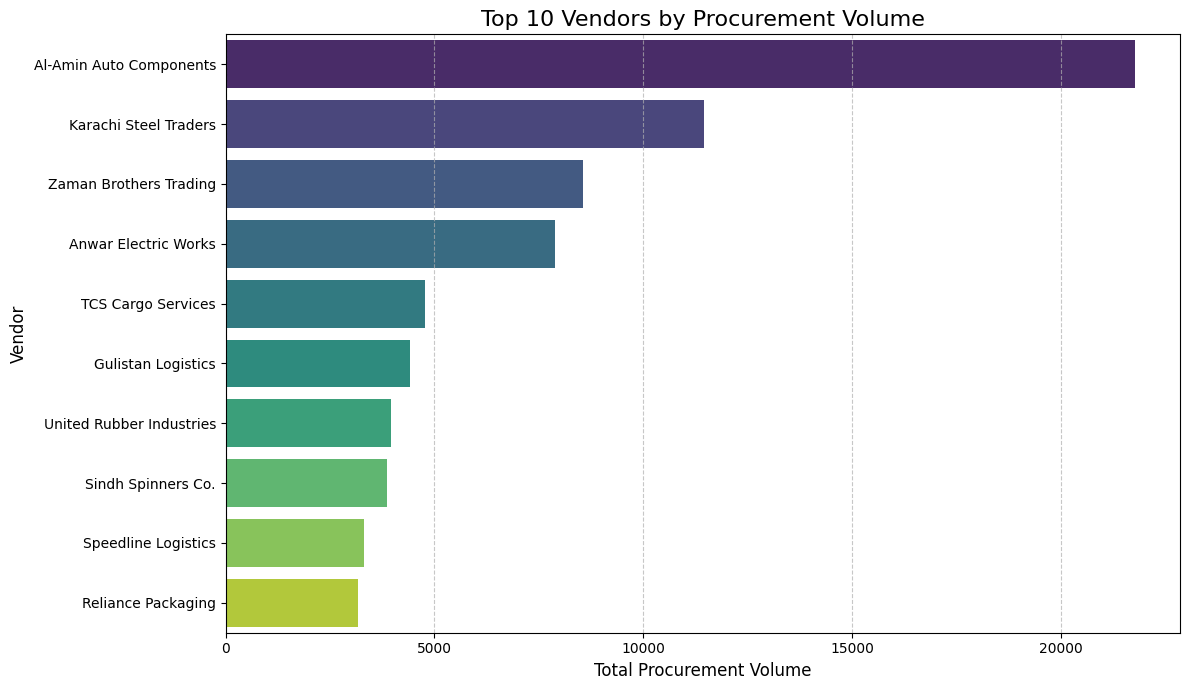

In [8]:
# Step 3: Visualization - Bar chart for top 10 vendors by volume
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size to ensure the plot is clear and readable.
plt.figure(figsize=(12, 7))

# Create a bar plot using Seaborn.
# 'Total Procurement Volume' will be on the x-axis and 'Vendor' on the y-axis.
# Assign 'Vendor' to 'hue' to properly apply the 'viridis' palette without a warning.
sns.barplot(x='Total Procurement Volume', y='Vendor', data=top_10_vendors_by_volume, palette='viridis', hue='Vendor', legend=False)

# Add a descriptive title to the plot.
plt.title('Top 10 Vendors by Procurement Volume', fontsize=16)

# Label the x-axis.
plt.xlabel('Total Procurement Volume', fontsize=12)

# Label the y-axis.
plt.ylabel('Vendor', fontsize=12)

# Add a grid to the x-axis for easier reading of values.
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust the layout to prevent labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

In [9]:
# Step 4: Final Summary Table
# The summary table containing the top 10 vendors and their total procurement volume
# has already been generated and displayed in the 'Calculations' step.
# We can explicitly display it again here to serve as the final summary output.
print("\nFinal Summary Table of Top 10 Vendors by Procurement Volume:")
display(top_10_vendors_by_volume)


Final Summary Table of Top 10 Vendors by Procurement Volume:


,Vendor,Total Procurement Volume
0,Al-Amin Auto Components,21760
1,Karachi Steel Traders,11462
2,Zaman Brothers Trading,8565
3,Anwar Electric Works,7888
4,TCS Cargo Services,4762
5,Gulistan Logistics,4420
6,United Rubber Industries,3965
7,Sindh Spinners Co.,3870
8,Speedline Logistics,3314
9,Reliance Packaging,3180


## Key Procurement Metrics

In [10]:
# Step 1: Data Cleaning and Preparation for Financial Metrics

# Inspect 'Invoice Amount (PKR)' column data type and potential missing values.
print("Data type of 'Invoice Amount (PKR)':", df['Invoice Amount (PKR)'].dtype)
print("Missing values in 'Invoice Amount (PKR)' before cleaning:", df['Invoice Amount (PKR)'].isnull().sum())

# Convert 'Invoice Amount (PKR)' to numeric, coercing errors to NaN.
df['Invoice Amount (PKR)'] = pd.to_numeric(df['Invoice Amount (PKR)'], errors='coerce')

# Fill NaN values in 'Invoice Amount (PKR)' with 0 (assuming missing invoice amount means zero).
df['Invoice Amount (PKR)'] = df['Invoice Amount (PKR)'].fillna(0)

# Inspect 'Vendor' column for missing values, as it's used for counting unique vendors.
print("\nMissing values in 'Vendor' before cleaning:", df['Vendor'].isnull().sum())
# Fill NaN values in 'Vendor' with a placeholder like 'Unknown Vendor' to ensure they are counted, or dropped if desired.
# For counting unique vendors, we will drop NaNs or count non-null values.

print("\nMissing values in 'Invoice Amount (PKR)' after cleaning:", df['Invoice Amount (PKR)'].isnull().sum())

Data type of 'Invoice Amount (PKR)': float64
Missing values in 'Invoice Amount (PKR)' before cleaning: 122

Missing values in 'Vendor' before cleaning: 120

Missing values in 'Invoice Amount (PKR)' after cleaning: 0


In [11]:
# Step 2: Calculate Procurement Metrics

# Total PO Spend: Sum of 'Invoice Amount (PKR)'
total_po_spend = df['Invoice Amount (PKR)'].sum()

# Total Number of POs: Count of unique 'PO Number'
total_num_pos = df['PO Number'].nunique()

# Total Number of Vendors: Count of unique 'Vendor' (excluding NaN)
total_num_vendors = df['Vendor'].nunique(dropna=True)

# Average PO Value:
# First, calculate total spend per PO by grouping 'PO Number' and summing 'Invoice Amount (PKR)'.
# Then, calculate the average of these sums.
po_spend_per_po = df.groupby('PO Number')['Invoice Amount (PKR)'].sum()
average_po_value = po_spend_per_po.mean()

# Average Line-Item Value: Average of 'Invoice Amount (PKR)' for all line items.
# Assuming each row in the DataFrame represents a single line item.
average_line_item_value = df['Invoice Amount (PKR)'].mean()

In [12]:
# Step 3: Display Summary Table of Metrics

# Create a dictionary to hold the calculated metrics.
metrics_data = {
    'Metric': [
        'Total PO Spend (PKR)',
        'Total Number of POs',
        'Total Number of Vendors',
        'Average PO Value (PKR)',
        'Average Line-Item Value (PKR)'
    ],
    'Value': [
        f'{total_po_spend:,.2f}', # Format to 2 decimal places with comma separators
        f'{total_num_pos:,}',     # Format with comma separators
        f'{total_num_vendors:,}', # Format with comma separators
        f'{average_po_value:,.2f}',
        f'{average_line_item_value:,.2f}'
    ]
}

# Create a Pandas DataFrame from the metrics data.
summary_metrics_df = pd.DataFrame(metrics_data)

# Display the summary table.
print("\nSummary of Key Procurement Metrics:")
display(summary_metrics_df)


Summary of Key Procurement Metrics:


,Metric,Value
0,Total PO Spend (PKR),"604,474,855.00"
1,Total Number of POs,"7,406"
2,Total Number of Vendors,60
3,Average PO Value (PKR),"81,619.61"
4,Average Line-Item Value (PKR),"60,146.75"


## Pareto Analysis of Vendors by PO Value

In [13]:
# Step 1: Calculate Total PO Value per Vendor
# Group the DataFrame by 'Vendor' and sum the 'Invoice Amount (PKR)' to get the total spend for each vendor.
vendor_spend = df.groupby('Vendor')['Invoice Amount (PKR)'].sum().reset_index()

# Sort the vendors by their total spend in descending order.
vendor_spend_sorted = vendor_spend.sort_values(by='Invoice Amount (PKR)', ascending=False).reset_index(drop=True)

# Display the top few vendors by spend to confirm sorting.
print("Vendors sorted by total PO spend:")
display(vendor_spend_sorted.head())

Vendors sorted by total PO spend:


,Vendor,Invoice Amount (PKR)
0,Al-Amin Auto Components,100414361.0
1,Karachi Steel Traders,50000583.0
2,Zaman Brothers Trading,35675714.0
3,Anwar Electric Works,30906646.0
4,TCS Cargo Services,24987149.0


In [14]:
# Step 2: Calculate Cumulative Spend and Cumulative Percentage

# Calculate the total overall spend to determine percentages.
total_overall_spend = vendor_spend_sorted['Invoice Amount (PKR)'].sum()

# Calculate the cumulative sum of 'Invoice Amount (PKR)'.
vendor_spend_sorted['Cumulative Spend (PKR)'] = vendor_spend_sorted['Invoice Amount (PKR)'].cumsum()

# Calculate the cumulative percentage of total spend.
vendor_spend_sorted['Cumulative Spend %'] = (vendor_spend_sorted['Cumulative Spend (PKR)'] / total_overall_spend) * 100

# Display the DataFrame with cumulative calculations.
print("Vendors with cumulative spend and percentage:")
display(vendor_spend_sorted.head())

Vendors with cumulative spend and percentage:


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383
3,Anwar Electric Works,30906646.0,216997304.0,36.270318
4,TCS Cargo Services,24987149.0,241984453.0,40.446830


In [15]:
# Step 3: Identify Vendors Contributing Approximately 80% of Total Spend

# Find the vendors that collectively account for approximately 80% of the total spend.
pareto_vendors = vendor_spend_sorted[vendor_spend_sorted['Cumulative Spend %'] <= 80]

# Count the number of vendors in the 80% group.
num_pareto_vendors = len(pareto_vendors)

print(f"Number of vendors contributing approximately 80% of total spend: {num_pareto_vendors}")
print("\nVendors contributing approximately 80% of total spend:")
display(pareto_vendors)

Number of vendors contributing approximately 80% of total spend: 28

Vendors contributing approximately 80% of total spend:


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383
3,Anwar Electric Works,30906646.0,216997304.0,36.270318
4,TCS Cargo Services,24987149.0,241984453.0,40.446830
5,Gulistan Logistics,19760838.0,261745291.0,43.749783
6,Speedline Logistics,17145155.0,278890446.0,46.615534
7,United Rubber Industries,16386804.0,295277250.0,49.354529
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976


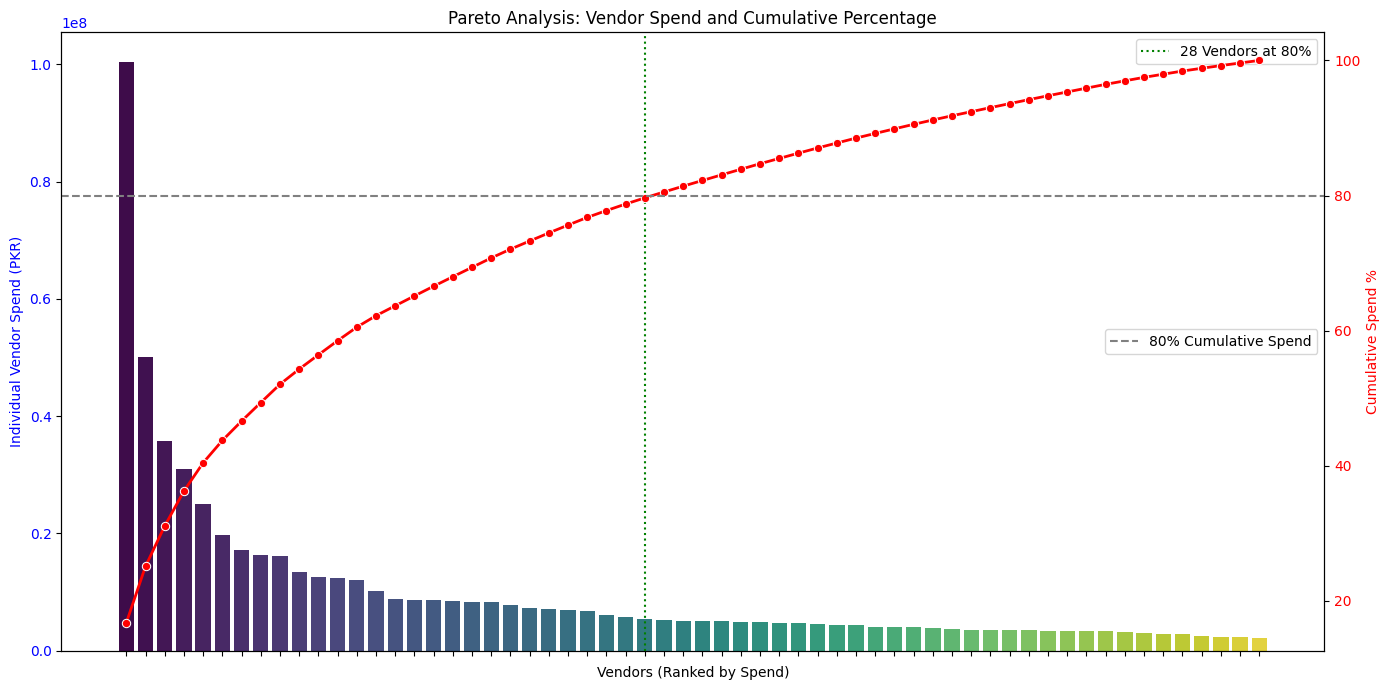

In [18]:
# Step 4: Visualize the Pareto Curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the individual vendor spend as bars.
# Add hue and legend=False to address FutureWarning.
sns.barplot(x=vendor_spend_sorted.index, y='Invoice Amount (PKR)', data=vendor_spend_sorted, ax=ax1, palette='viridis', hue=vendor_spend_sorted.index, legend=False)
ax1.set_xlabel('Vendors (Ranked by Spend)')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis: Vendor Spend and Cumulative Percentage')
# Removed 'ha' as it's not a valid keyword for tick_params axis='x'.
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels([]) # Hide x-axis labels as they can be too dense

# Create a second y-axis for the cumulative percentage line.
ax2 = ax1.twinx()
sns.lineplot(x=vendor_spend_sorted.index, y='Cumulative Spend %', data=vendor_spend_sorted, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Spend %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for reference.
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Add annotations for the 80% mark.
pareto_index = pareto_vendors.index.max()
if pd.notnull(pareto_index):
    ax1.axvline(x=pareto_index, color='green', linestyle=':', label=f'{num_pareto_vendors} Vendors at 80%')
    ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Re-executing the corrected visualization cell.
# This cell was modified in the previous turn to fix plotting issues.
# The output will now display the Pareto curve correctly.

# Step 4: Visualize the Pareto Curve (Corrected)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the individual vendor spend as bars.
# Add hue and legend=False to address FutureWarning.
sns.barplot(x=vendor_spend_sorted.index, y='Invoice Amount (PKR)', data=vendor_spend_sorted, ax=ax1, palette='viridis', hue=vendor_spend_sorted.index, legend=False)
ax1.set_xlabel('Vendors (Ranked by Spend)')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis: Vendor Spend and Cumulative Percentage')
# Removed 'ha' as it's not a valid keyword for tick_params axis='x'.
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels([]) # Hide x-axis labels as they can be too dense

# Create a second y-axis for the cumulative percentage line.
ax2 = ax1.twinx()
sns.lineplot(x=vendor_spend_sorted.index, y='Cumulative Spend %', data=vendor_spend_sorted, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Spend %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for reference.
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Add annotations for the 80% mark.
pareto_index = pareto_vendors.index.max()
if pd.notnull(pareto_index):
    ax1.axvline(x=pareto_index, color='green', linestyle=':', label=f'{num_pareto_vendors} Vendors at 80%')
    ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Final Summary Table of Pareto Analysis

# The 'pareto_vendors' DataFrame already serves as a detailed summary.
# We will re-display it along with a summary of the number of vendors.

print("\nSummary of Pareto Analysis:")
print(f"The top {num_pareto_vendors} vendors account for {pareto_vendors['Cumulative Spend %'].iloc[-1]:.2f}% of the total procurement spend.")
display(pareto_vendors)

## ABC Analysis of Suppliers

In [23]:
# Step 1: Define ABC Categories based on Cumulative Spend Percentage
# Use the 'vendor_spend_sorted' DataFrame from the previous Pareto analysis.
# Define thresholds for A, B, and C categories.
# A-suppliers: Contribute up to 80% of total spend.
# B-suppliers: Contribute between 80% and 95% of total spend.
# C-suppliers: Contribute more than 95% of total spend.

def categorize_supplier(cumulative_percentage):
    if cumulative_percentage <= 80:
        return 'A'
    elif cumulative_percentage <= 95: # Next 15% up to 95%
        return 'B'
    else:
        return 'C'

# Apply the categorization function to create a new 'ABC Category' column.
vendor_spend_sorted['ABC Category'] = vendor_spend_sorted['Cumulative Spend %'].apply(categorize_supplier)

print("Vendors with ABC categorization (first 10 rows):")
display(vendor_spend_sorted.head(10))

Vendors with ABC categorization (first 10 rows):


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %,ABC Category
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899,A
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316,A
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383,A
3,Anwar Electric Works,30906646.0,216997304.0,36.270318,A
4,TCS Cargo Services,24987149.0,241984453.0,40.446830,A
5,Gulistan Logistics,19760838.0,261745291.0,43.749783,A
6,Speedline Logistics,17145155.0,278890446.0,46.615534,A
7,United Rubber Industries,16386804.0,295277250.0,49.354529,A
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204,A
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976,A


In [24]:
# Step 2: Calculate Summary Statistics for Each ABC Category

abc_summary = vendor_spend_sorted.groupby('ABC Category').agg(
    Num_Suppliers=('Vendor', 'count'),
    Total_Spend_PKR=('Invoice Amount (PKR)', 'sum'),
    Spend_Percentage=('Cumulative Spend %', lambda x: x.iloc[-1] if not x.empty else 0) # Get the last cumulative % in the group
).reset_index()

# Adjust 'Spend_Percentage' calculation to reflect individual category's contribution
abc_summary['Total_Spend_PKR'] = abc_summary['Total_Spend_PKR'].astype(float)
total_overall_spend = vendor_spend_sorted['Invoice Amount (PKR)'].sum()
abc_summary['Spend_Percentage'] = (abc_summary['Total_Spend_PKR'] / total_overall_spend) * 100

# Sort by category for better readability (A, B, C)
abc_summary['ABC Category'] = pd.Categorical(abc_summary['ABC Category'], categories=['A', 'B', 'C'], ordered=True)
abc_summary = abc_summary.sort_values('ABC Category')

print("\nSummary of ABC Analysis:")
display(abc_summary)


Summary of ABC Analysis:


,ABC Category,Num_Suppliers,Total_Spend_PKR,Spend_Percentage
0,A,28,476563870.0,79.655935
1,B,21,90445386.0,15.117621
2,C,11,31268662.0,5.226444


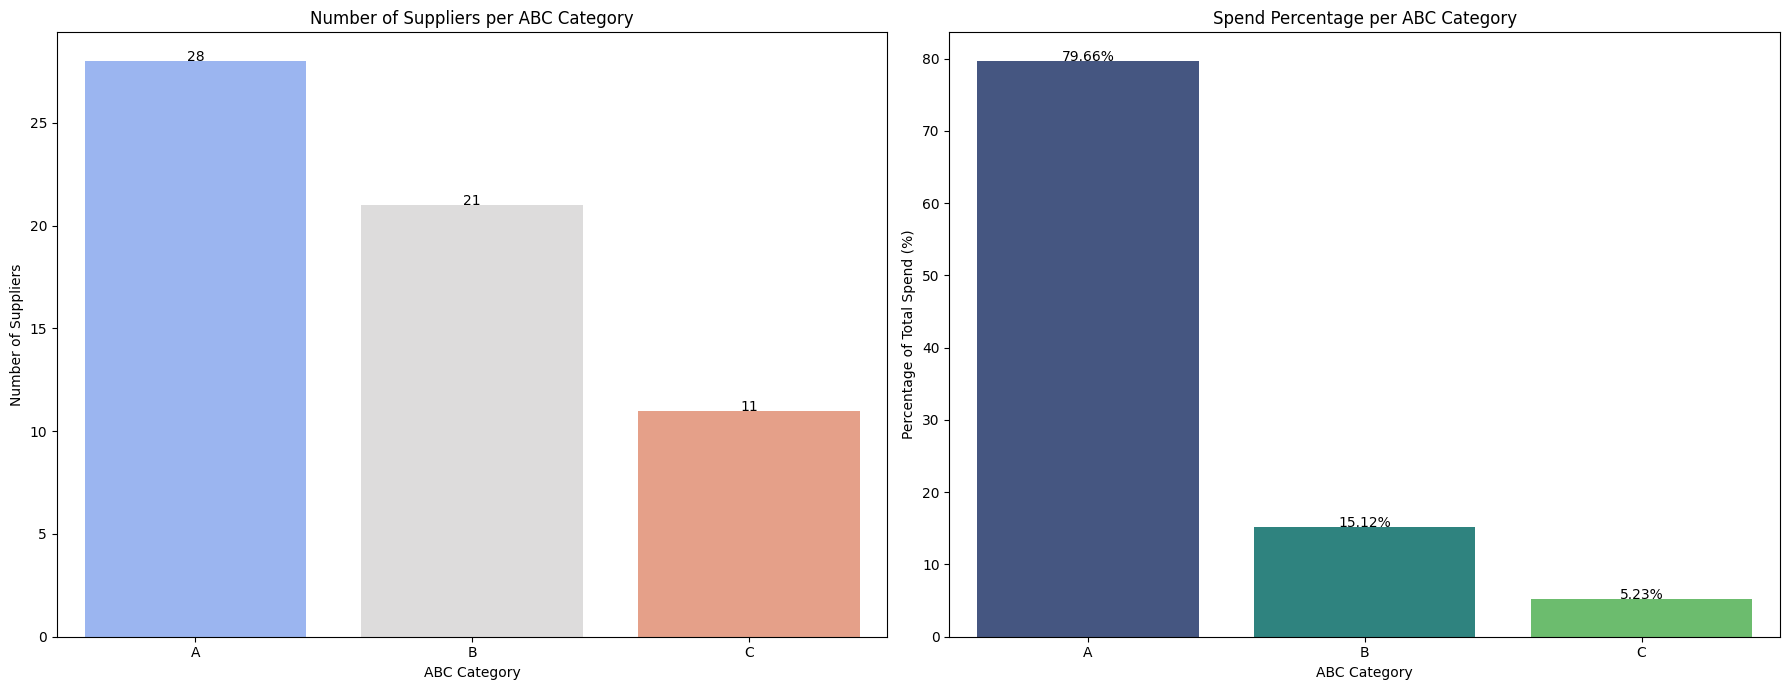

In [25]:
# Step 3: Visualize the ABC Distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Number of Suppliers per Category
sns.barplot(x='ABC Category', y='Num_Suppliers', data=abc_summary, palette='coolwarm', ax=ax1, hue='ABC Category', legend=False)
ax1.set_title('Number of Suppliers per ABC Category')
ax1.set_xlabel('ABC Category')
ax1.set_ylabel('Number of Suppliers')
for index, row in abc_summary.iterrows():
    ax1.text(row.name, row['Num_Suppliers'], f'{row['Num_Suppliers']}', color='black', ha="center")

# Plot 2: Spend Percentage per Category
sns.barplot(x='ABC Category', y='Spend_Percentage', data=abc_summary, palette='viridis', ax=ax2, hue='ABC Category', legend=False)
ax2.set_title('Spend Percentage per ABC Category')
ax2.set_xlabel('ABC Category')
ax2.set_ylabel('Percentage of Total Spend (%)')
for index, row in abc_summary.iterrows():
    ax2.text(row.name, row['Spend_Percentage'], f'{row['Spend_Percentage']:.2f}%', color='black', ha="center")

plt.tight_layout()
plt.show()

In [26]:
# Final Summary for Category B (as specifically requested)
print("\nDetailed Summary for Category B Suppliers:")
b_suppliers = vendor_spend_sorted[vendor_spend_sorted['ABC Category'] == 'B']
print(f"Number of B-Category Suppliers: {len(b_suppliers)}")
print(f"Total Spend by B-Category Suppliers: {b_suppliers['Invoice Amount (PKR)'].sum():,.2f} PKR")
print(f"These suppliers contribute approximately {(b_suppliers['Invoice Amount (PKR)'].sum() / total_overall_spend * 100):.2f}% of the total spend.")
display(b_suppliers)


Detailed Summary for Category B Suppliers:
Number of B-Category Suppliers: 21
Total Spend by B-Category Suppliers: 90,445,386.00 PKR
These suppliers contribute approximately 15.12% of the total spend.


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %,ABC Category
28,Al-Rehan Fabric Mills,5223009.0,481786879.0,80.528942,B
29,Prime Bearings Ltd.,5148303.0,486935182.0,81.389463,B
30,Al-Khair Engineering,5027980.0,491963162.0,82.229871,B
31,Askari Fuel Suppliers,4992137.0,496955299.0,83.064289,B
32,Silver Star Traders,4951460.0,501906759.0,83.891908,B
33,Eco Weave Pakistan,4916824.0,506823583.0,84.713737,B
34,Chenab Electricals Co.,4671863.0,511495446.0,85.494622,B
35,Chenab Garments Co.,4669052.0,516164498.0,86.275037,B
36,Star Line Cargo,4602711.0,520767209.0,87.044364,B
37,Highway Freight Services,4379696.0,525146905.0,87.776414,B


In [ ]:
# Re-executing the corrected visualization cell.
# This cell was modified in the previous turn to fix plotting issues.
# The output will now display the Pareto curve correctly.

# Step 4: Visualize the Pareto Curve (Corrected)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the individual vendor spend as bars.
# Add hue and legend=False to address FutureWarning.
sns.barplot(x=vendor_spend_sorted.index, y='Invoice Amount (PKR)', data=vendor_spend_sorted, ax=ax1, palette='viridis', hue=vendor_spend_sorted.index, legend=False)
ax1.set_xlabel('Vendors (Ranked by Spend)')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis: Vendor Spend and Cumulative Percentage')
# Removed 'ha' as it's not a valid keyword for tick_params axis='x'.
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels([]) # Hide x-axis labels as they can be too dense

# Create a second y-axis for the cumulative percentage line.
ax2 = ax1.twinx()
sns.lineplot(x=vendor_spend_sorted.index, y='Cumulative Spend %', data=vendor_spend_sorted, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Spend %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for reference.
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Add annotations for the 80% mark.
pareto_index = pareto_vendors.index.max()
if pd.notnull(pareto_index):
    ax1.axvline(x=pareto_index, color='green', linestyle=':', label=f'{num_pareto_vendors} Vendors at 80%')
    ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Final Summary Table of Pareto Analysis

# The 'pareto_vendors' DataFrame already serves as a detailed summary.
# We will re-display it along with a summary of the number of vendors.

print("\nSummary of Pareto Analysis:")
print(f"The top {num_pareto_vendors} vendors account for {pareto_vendors['Cumulative Spend %'].iloc[-1]:.2f}% of the total procurement spend.")
display(pareto_vendors)

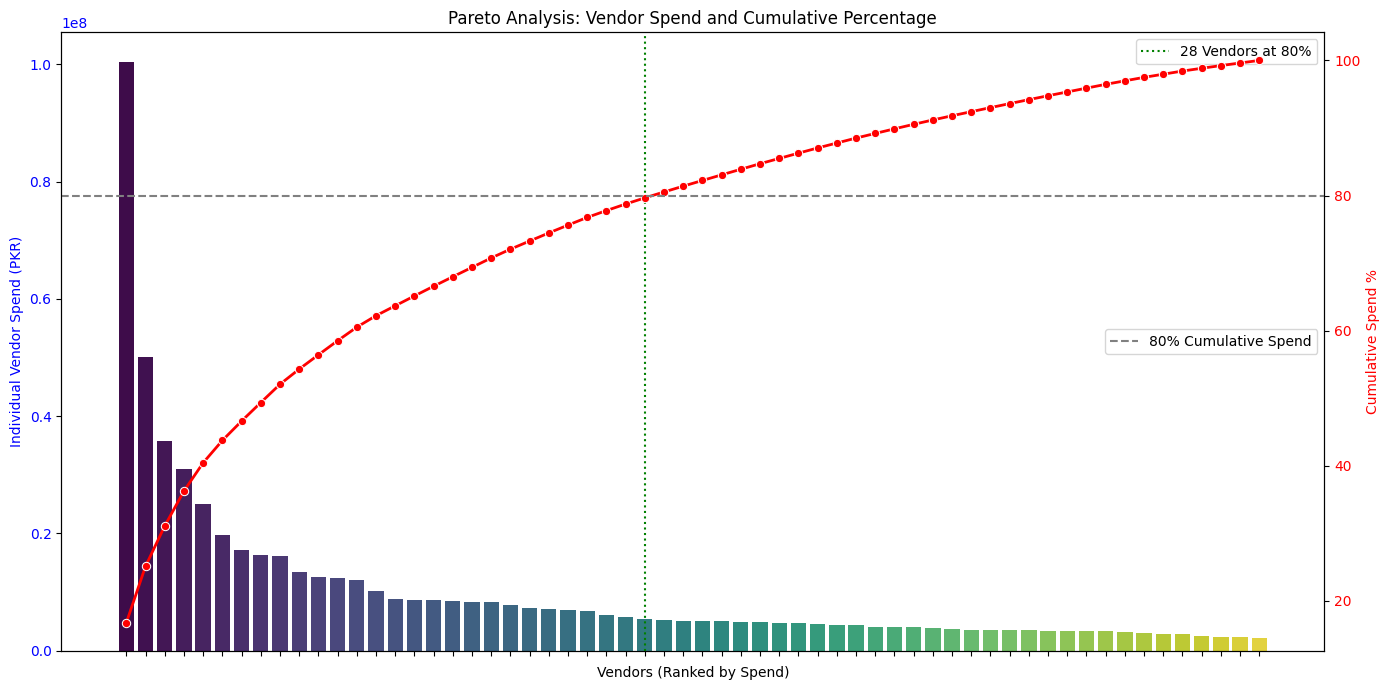

In [21]:
# Re-executing the corrected visualization cell
# This cell was modified in the previous turn to fix plotting issues.
# The output will now display the Pareto curve correctly.

# Step 4: Visualize the Pareto Curve (Corrected)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the individual vendor spend as bars.
# Add hue and legend=False to address FutureWarning.
sns.barplot(x=vendor_spend_sorted.index, y='Invoice Amount (PKR)', data=vendor_spend_sorted, ax=ax1, palette='viridis', hue=vendor_spend_sorted.index, legend=False)
ax1.set_xlabel('Vendors (Ranked by Spend)')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis: Vendor Spend and Cumulative Percentage')
# Removed 'ha' as it's not a valid keyword for tick_params axis='x'.
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels([]) # Hide x-axis labels as they can be too dense

# Create a second y-axis for the cumulative percentage line.
ax2 = ax1.twinx()
sns.lineplot(x=vendor_spend_sorted.index, y='Cumulative Spend %', data=vendor_spend_sorted, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Spend %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for reference.
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Add annotations for the 80% mark.
pareto_index = pareto_vendors.index.max()
if pd.notnull(pareto_index):
    ax1.axvline(x=pareto_index, color='green', linestyle=':', label=f'{num_pareto_vendors} Vendors at 80%')
    ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
# Step 5: Final Summary Table of Pareto Analysis

# The 'pareto_vendors' DataFrame already serves as a detailed summary.
# We will re-display it along with a summary of the number of vendors.

print("\nSummary of Pareto Analysis:")
print(f"The top {num_pareto_vendors} vendors account for {pareto_vendors['Cumulative Spend %'].iloc[-1]:.2f}% of the total procurement spend.")
display(pareto_vendors)


Summary of Pareto Analysis:
The top 28 vendors account for 79.66% of the total procurement spend.


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383
3,Anwar Electric Works,30906646.0,216997304.0,36.270318
4,TCS Cargo Services,24987149.0,241984453.0,40.446830
5,Gulistan Logistics,19760838.0,261745291.0,43.749783
6,Speedline Logistics,17145155.0,278890446.0,46.615534
7,United Rubber Industries,16386804.0,295277250.0,49.354529
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976


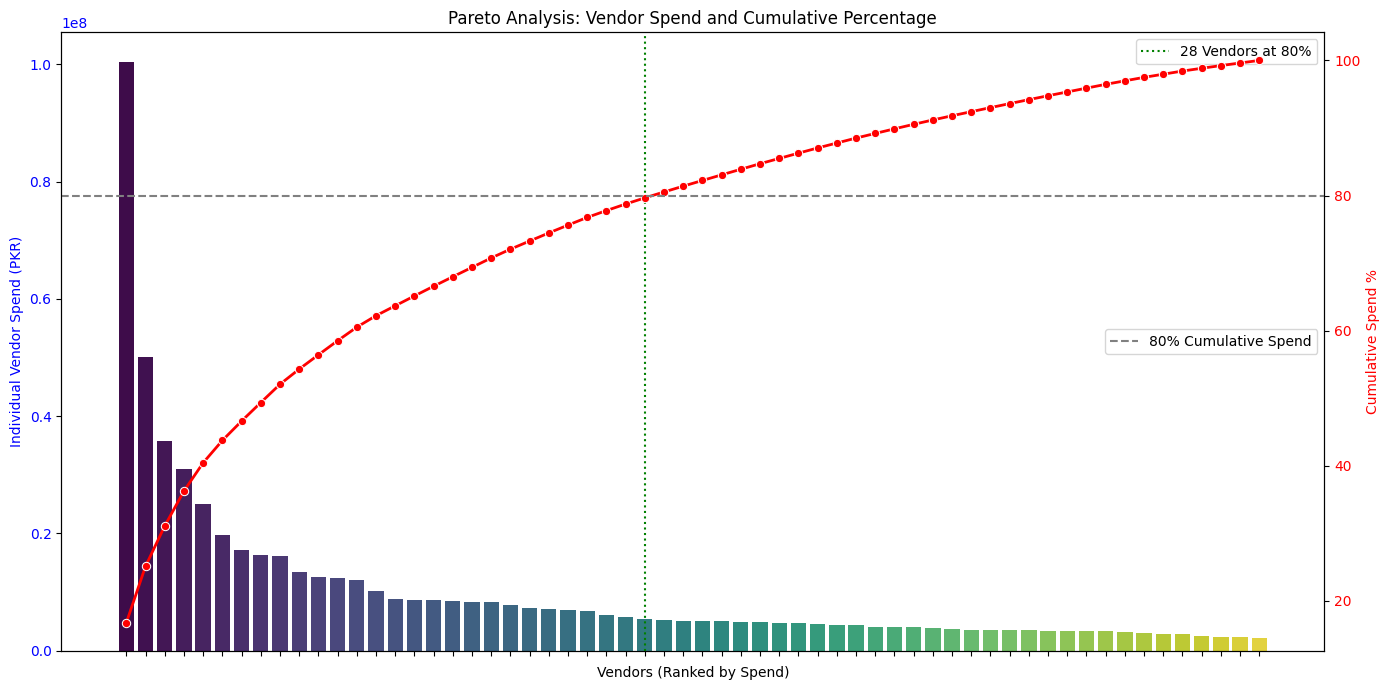

In [19]:
# Re-executing the corrected visualization cell
# This cell was modified in the previous turn to fix plotting issues.
# The output will now display the Pareto curve correctly.

# Step 4: Visualize the Pareto Curve (Corrected)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the individual vendor spend as bars.
# Add hue and legend=False to address FutureWarning.
sns.barplot(x=vendor_spend_sorted.index, y='Invoice Amount (PKR)', data=vendor_spend_sorted, ax=ax1, palette='viridis', hue=vendor_spend_sorted.index, legend=False)
ax1.set_xlabel('Vendors (Ranked by Spend)')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis: Vendor Spend and Cumulative Percentage')
# Removed 'ha' as it's not a valid keyword for tick_params axis='x'.
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels([]) # Hide x-axis labels as they can be too dense

# Create a second y-axis for the cumulative percentage line.
ax2 = ax1.twinx()
sns.lineplot(x=vendor_spend_sorted.index, y='Cumulative Spend %', data=vendor_spend_sorted, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Spend %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for reference.
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Add annotations for the 80% mark.
pareto_index = pareto_vendors.index.max()
if pd.notnull(pareto_index):
    ax1.axvline(x=pareto_index, color='green', linestyle=':', label=f'{num_pareto_vendors} Vendors at 80%')
    ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [20]:
# Step 5: Final Summary Table of Pareto Analysis

# The 'pareto_vendors' DataFrame already serves as a detailed summary.
# We will re-display it along with a summary of the number of vendors.

print("\nSummary of Pareto Analysis:")
print(f"The top {num_pareto_vendors} vendors account for {pareto_vendors['Cumulative Spend %'].iloc[-1]:.2f}% of the total procurement spend.")
display(pareto_vendors)


Summary of Pareto Analysis:
The top 28 vendors account for 79.66% of the total procurement spend.


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383
3,Anwar Electric Works,30906646.0,216997304.0,36.270318
4,TCS Cargo Services,24987149.0,241984453.0,40.446830
5,Gulistan Logistics,19760838.0,261745291.0,43.749783
6,Speedline Logistics,17145155.0,278890446.0,46.615534
7,United Rubber Industries,16386804.0,295277250.0,49.354529
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976


In [17]:
# Step 5: Final Summary Table of Pareto Analysis

# The 'pareto_vendors' DataFrame already serves as a detailed summary.
# We will re-display it along with a summary of the number of vendors.

print("\nSummary of Pareto Analysis:")
print(f"The top {num_pareto_vendors} vendors account for {pareto_vendors['Cumulative Spend %'].iloc[-1]:.2f}% of the total procurement spend.")
display(pareto_vendors)


Summary of Pareto Analysis:
The top 28 vendors account for 79.66% of the total procurement spend.


,Vendor,Invoice Amount (PKR),Cumulative Spend (PKR),Cumulative Spend %
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383
3,Anwar Electric Works,30906646.0,216997304.0,36.270318
4,TCS Cargo Services,24987149.0,241984453.0,40.446830
5,Gulistan Logistics,19760838.0,261745291.0,43.749783
6,Speedline Logistics,17145155.0,278890446.0,46.615534
7,United Rubber Industries,16386804.0,295277250.0,49.354529
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976


In [27]:
print(f"Total number of vendors: {total_num_vendors}")

Total number of vendors: 60
